In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import os
import random
import skimage.data
import skimage.transform
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
from collections import Counter
from PIL import Image
from glob import glob
import shutil
import pandas as pd
from ultralytics import YOLO
import yaml
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
files.upload() # Upload kaggle.json API file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahkarhtet","key":"278187fba88c98581bb038a240a99824"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip gtsrb-german-traffic-sign.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/5/00005_00053_00010.png  
  inflating: train/5/00005_00053_00011.png  
  inflating: train/5/00005_00053_00012.png  
  inflating: train/5/00005_00053_00013.png  
  inflating: train/5/00005_00053_00014.png  
  inflating: train/5/00005_00053_00015.png  
  inflating: train/5/00005_00053_00016.png  
  inflating: train/5/00005_00053_00017.png  
  inflating: train/5/00005_00053_00018.png  
  inflating: train/5/00005_00053_00019.png  
  inflating: train/5/00005_00053_00020.png  
  inflating: train/5/00005_00053_00021.png  
  inflating: train/5/00005_00053_00022.png  
  inflating: train/5/00005_00053_00023.png  
  inflating: train/5/00005_00053_00024.png  
  inflating: train/5/00005_00053_00025.png  
  inflating: train/5/00005_00053_00026.png  
  inflating: train/5/00005_00053_00027.png  
  inflating: train/5/00005_00053_00028.png  
  inflating: train/5/00005_00053_00029.png  
  inflating: train/5/00005_00054_00000.png  
  in

In [ ]:
# Load the CSVs
train_df = pd.read_csv("/content/Train.csv")
test_df = pd.read_csv("/content/Test.csv")
meta_df = pd.read_csv("/content/Meta.csv")

# Merge all datasets
full_df = pd.concat([train_df, test_df, meta_df], ignore_index=True)

# Drop missing annotations
full_df = full_df.dropna(subset=['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2'])


In [ ]:
TARGET = 600
filtered_rows = []

# Count per class
counts = full_df['ClassId'].value_counts()

# Keep only those with ≥ 500
valid_classes = counts[counts >= TARGET].index.tolist()

for class_id in valid_classes:
    class_data = full_df[full_df['ClassId'] == class_id]
    sampled = class_data.sample(n=TARGET, random_state=42)
    filtered_rows.append(sampled)

balanced_df = pd.concat(filtered_rows).reset_index(drop=True)


In [ ]:
# Count how many unique classes are left
num_classes = balanced_df['ClassId'].nunique()

# Count samples per class
class_distribution = balanced_df['ClassId'].value_counts().sort_index()

# Display results
print(f"✅ Number of classes after balancing: {num_classes}\n")
print("📋 Dataset shape:\n")
print(balanced_df.shape)


✅ Number of classes after balancing: 25

📋 Dataset shape:

(15000, 11)


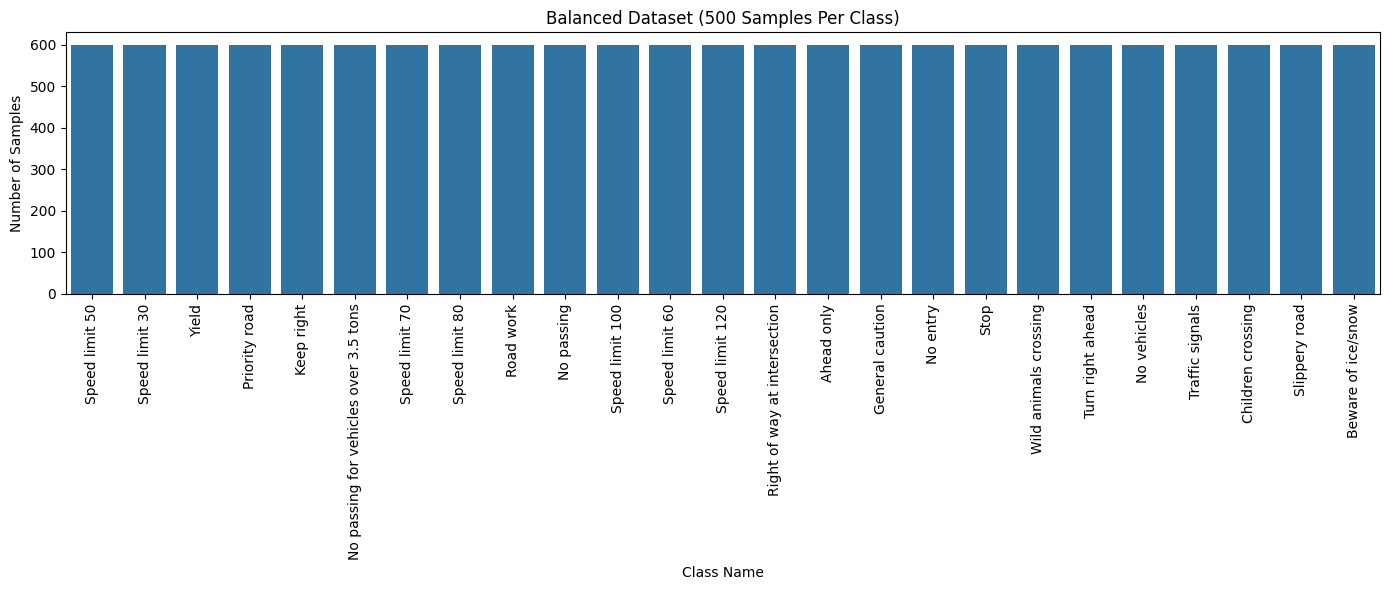

In [ ]:
# Manually defined class names (GTSRB 43 classes)
class_names = [
    "Speed limit 20", "Speed limit 30", "Speed limit 50", "Speed limit 60", "Speed limit 70", "Speed limit 80",
    "End of speed limit 80", "Speed limit 100", "Speed limit 120", "No passing",
    "No passing for vehicles over 3.5 tons", "Right of way at intersection", "Priority road", "Yield", "Stop",
    "No vehicles", "Vehicles over 3.5 tons prohibited", "No entry", "General caution", "Dangerous curve left",
    "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road", "Road narrows",
    "Road work", "Traffic signals", "Pedestrian crossing", "Children crossing", "Bicycles crossing",
    "Beware of ice/snow", "Wild animals crossing", "End all speed and passing limits", "Turn right ahead",
    "Turn left ahead", "Ahead only", "Go straight or right", "Go straight or left", "Keep right",
    "Keep left", "Roundabout", "End of no passing", "End of no passing vehicles > 3.5 tons"
]

# Create ID to label map
id_to_label = {i: name for i, name in enumerate(class_names)}

# Apply mapping to balanced dataframe
balanced_df["ClassName"] = balanced_df["ClassId"].map(id_to_label)

# Plot updated visual
plt.figure(figsize=(14, 6))
sns.countplot(data=balanced_df, x='ClassName', order=balanced_df['ClassName'].value_counts().index)
plt.title("Balanced Dataset (500 Samples Per Class)")
plt.xticks(rotation=90)
plt.xlabel("Class Name")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [ ]:
# STEP 4: Split into train/val/test
train_df, temp_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df["ClassId"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["ClassId"], random_state=42)

# Create class_id mapping (from original ID to 0-based index)
selected_classes = sorted(balanced_df["ClassId"].unique())
class_id_mapping = {orig_id: new_idx for new_idx, orig_id in enumerate(selected_classes)}

# Setup folder structure and export
base_path = "/content/yolo_dataset"
splits = {"train": train_df, "val": val_df, "test": test_df}

for split, df in splits.items():
    img_dir = f"{base_path}/{split}/images"
    label_dir = f"{base_path}/{split}/labels"
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)

    for _, row in df.iterrows():
        # Original image path
        img_path = os.path.join("/content", row["Path"])
        img_name = os.path.basename(row["Path"])
        label_name = img_name.replace(".png", ".txt")

        # Copy image to YOLO folder
        shutil.copy(img_path, os.path.join(img_dir, img_name))

        # Bounding box in YOLO format
        width, height = row["Width"], row["Height"]
        x_center = ((row["Roi.X1"] + row["Roi.X2"]) / 2) / width
        y_center = ((row["Roi.Y1"] + row["Roi.Y2"]) / 2) / height
        w = (row["Roi.X2"] - row["Roi.X1"]) / width
        h = (row["Roi.Y2"] - row["Roi.Y1"]) / height

        # Map to YOLO class ID
        mapped_id = class_id_mapping[int(row["ClassId"])]

        # Write .txt label
        with open(os.path.join(label_dir, label_name), "w") as f:
            f.write(f"{mapped_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

In [ ]:
# Create YAML for training
selected_classes = sorted(balanced_df["ClassId"].unique())
selected_names = [id_to_label[i] for i in selected_classes]

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(f"path: {base_path}\n")
    f.write(f"train: train/images\n")
    f.write(f"val: val/images\n")
    f.write(f"test: test/images\n")
    f.write(f"nc: {len(selected_classes)}\n")
    f.write(f"names: {selected_names}\n")


In [ ]:
# Load and validate data.yaml
yaml_path = "/content/yolo_dataset/data.yaml"

with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

num_classes = len(data_cfg['names'])
print(f"✅ Detected {num_classes} classes from data.yaml")

# Load the YOLOv8 pretrained model
model = YOLO("yolov8n.pt")

# Freeze all layers except the detection head
for name, param in model.model.named_parameters():
    if 'head' not in name:
        param.requires_grad = False
print("✅ Backbone frozen, only head will be trained.")

# Train the model
model.train(
    data=yaml_path,         # uses your class names and nc automatically
    epochs=15,
    imgsz=640,              # input size
    batch=32,               # adjust based on GPU RAM
    augment=True,
    save=True,
    name="custom_yolo_train"  # custom name for run folder
)

✅ Detected 25 classes from data.yaml
✅ Backbone frozen, only head will be trained.
Ultralytics 8.3.109 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/yolo_dataset/data.yaml, epochs=15, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=custom_yolo_train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=Fal

train: Scanning /content/yolo_dataset/train/labels... 12000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 12000/12000 [00:04<00:00, 2682.03it/s]


train: New cache created: /content/yolo_dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/yolo_dataset/val/labels... 1500 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1500/1500 [00:01<00:00, 1101.77it/s]

val: New cache created: /content/yolo_dataset/val/labels.cache


...

                   all       1500       1500      0.996      0.995      0.994      0.952



15 epochs completed in 0.827 hours.
Optimizer stripped from runs/detect/custom_yolo_train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/custom_yolo_train2/weights/best.pt, 6.2MB

Validating runs/detect/custom_yolo_train2/weights/best.pt...
Ultralytics 8.3.109 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:18<00:00,  1.31it/s]


                   all       1500       1500      0.997      0.996      0.995      0.955
        Speed limit 30         60         60      0.998      0.983      0.995      0.961
        Speed limit 50         60         60      0.996          1      0.995       0.95
        Speed limit 60         60         60      0.996      0.967      0.994      0.948
        Speed limit 70         60         60          1       0.97      0.995      0.955
        Speed limit 80         60         60      0.966          1      0.994      0.943
       Speed limit 100         60         60      0.998          1      0.995      0.949
       Speed limit 120         60         60      0.996      0.983      0.995      0.928
            No passing         60         60      0.998          1      0.995      0.968
No passing for vehicles over 3.5 tons         60         60      0.999          1      0.995      0.966
Right of way at intersection         60         60      0.999          1      0.995      0.962


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7db5090be490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,  

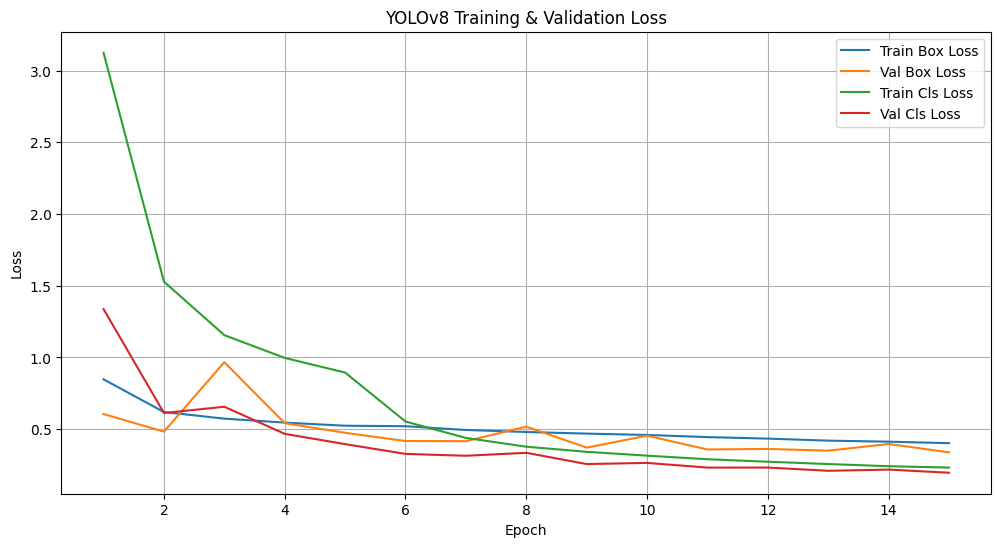

In [ ]:
# Load the training log
results_path = "runs/detect/custom_yolo_train2/results.csv"
df = pd.read_csv(results_path)

# Plot train and val losses
plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8 Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Evaluate the model on validation and test sets
metrics = model.val()
print("✅ Evaluation complete. Metrics:")
print(metrics)


Ultralytics 8.3.109 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/yolo_dataset/val/labels.cache... 1500 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1500/1500 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 47/47 [00:21<00:00,  2.21it/s]


                   all       1500       1500      0.997      0.995      0.995      0.955
        Speed limit 30         60         60      0.998      0.983      0.995      0.956
        Speed limit 50         60         60      0.996          1      0.995      0.949
        Speed limit 60         60         60      0.996      0.967      0.994      0.948
        Speed limit 70         60         60          1       0.97      0.995      0.955
        Speed limit 80         60         60      0.966          1      0.994      0.943
       Speed limit 100         60         60      0.998          1      0.995      0.949
       Speed limit 120         60         60      0.991      0.983      0.995      0.926
            No passing         60         60      0.998          1      0.995      0.968
No passing for vehicles over 3.5 tons         60         60      0.999          1      0.995      0.968
Right of way at intersection         60         60      0.999          1      0.995      0.963


In [ ]:
import os
import matplotlib.pyplot as plt

# Run prediction on a few test images
results = model.predict(
    source="/content/yolo_dataset/test/images",  
    conf=0.3,
    save=True,
    stream=False
)





WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1500 /content/yolo_dataset/test/images/00001_00001_00013.png: 640x640 1 Speed limit 30, 80.4ms
image 2/1500 /content/yolo_dataset/test/images/00001_00002_00003.png: 640x640 1 Speed limit 30, 23.2ms
image 3/1500 /content/yolo_dataset/test/images/00001_00003_00021.png: 640x640 1 Speed limit 30, 22.6ms
image 4/1500 /content/yolo_dataset/test/images/00001_00009_00021.png: 640x640 1 Speed limit 30, 24.9ms
image 5/1500 /content/yolo_dataset/test/imag

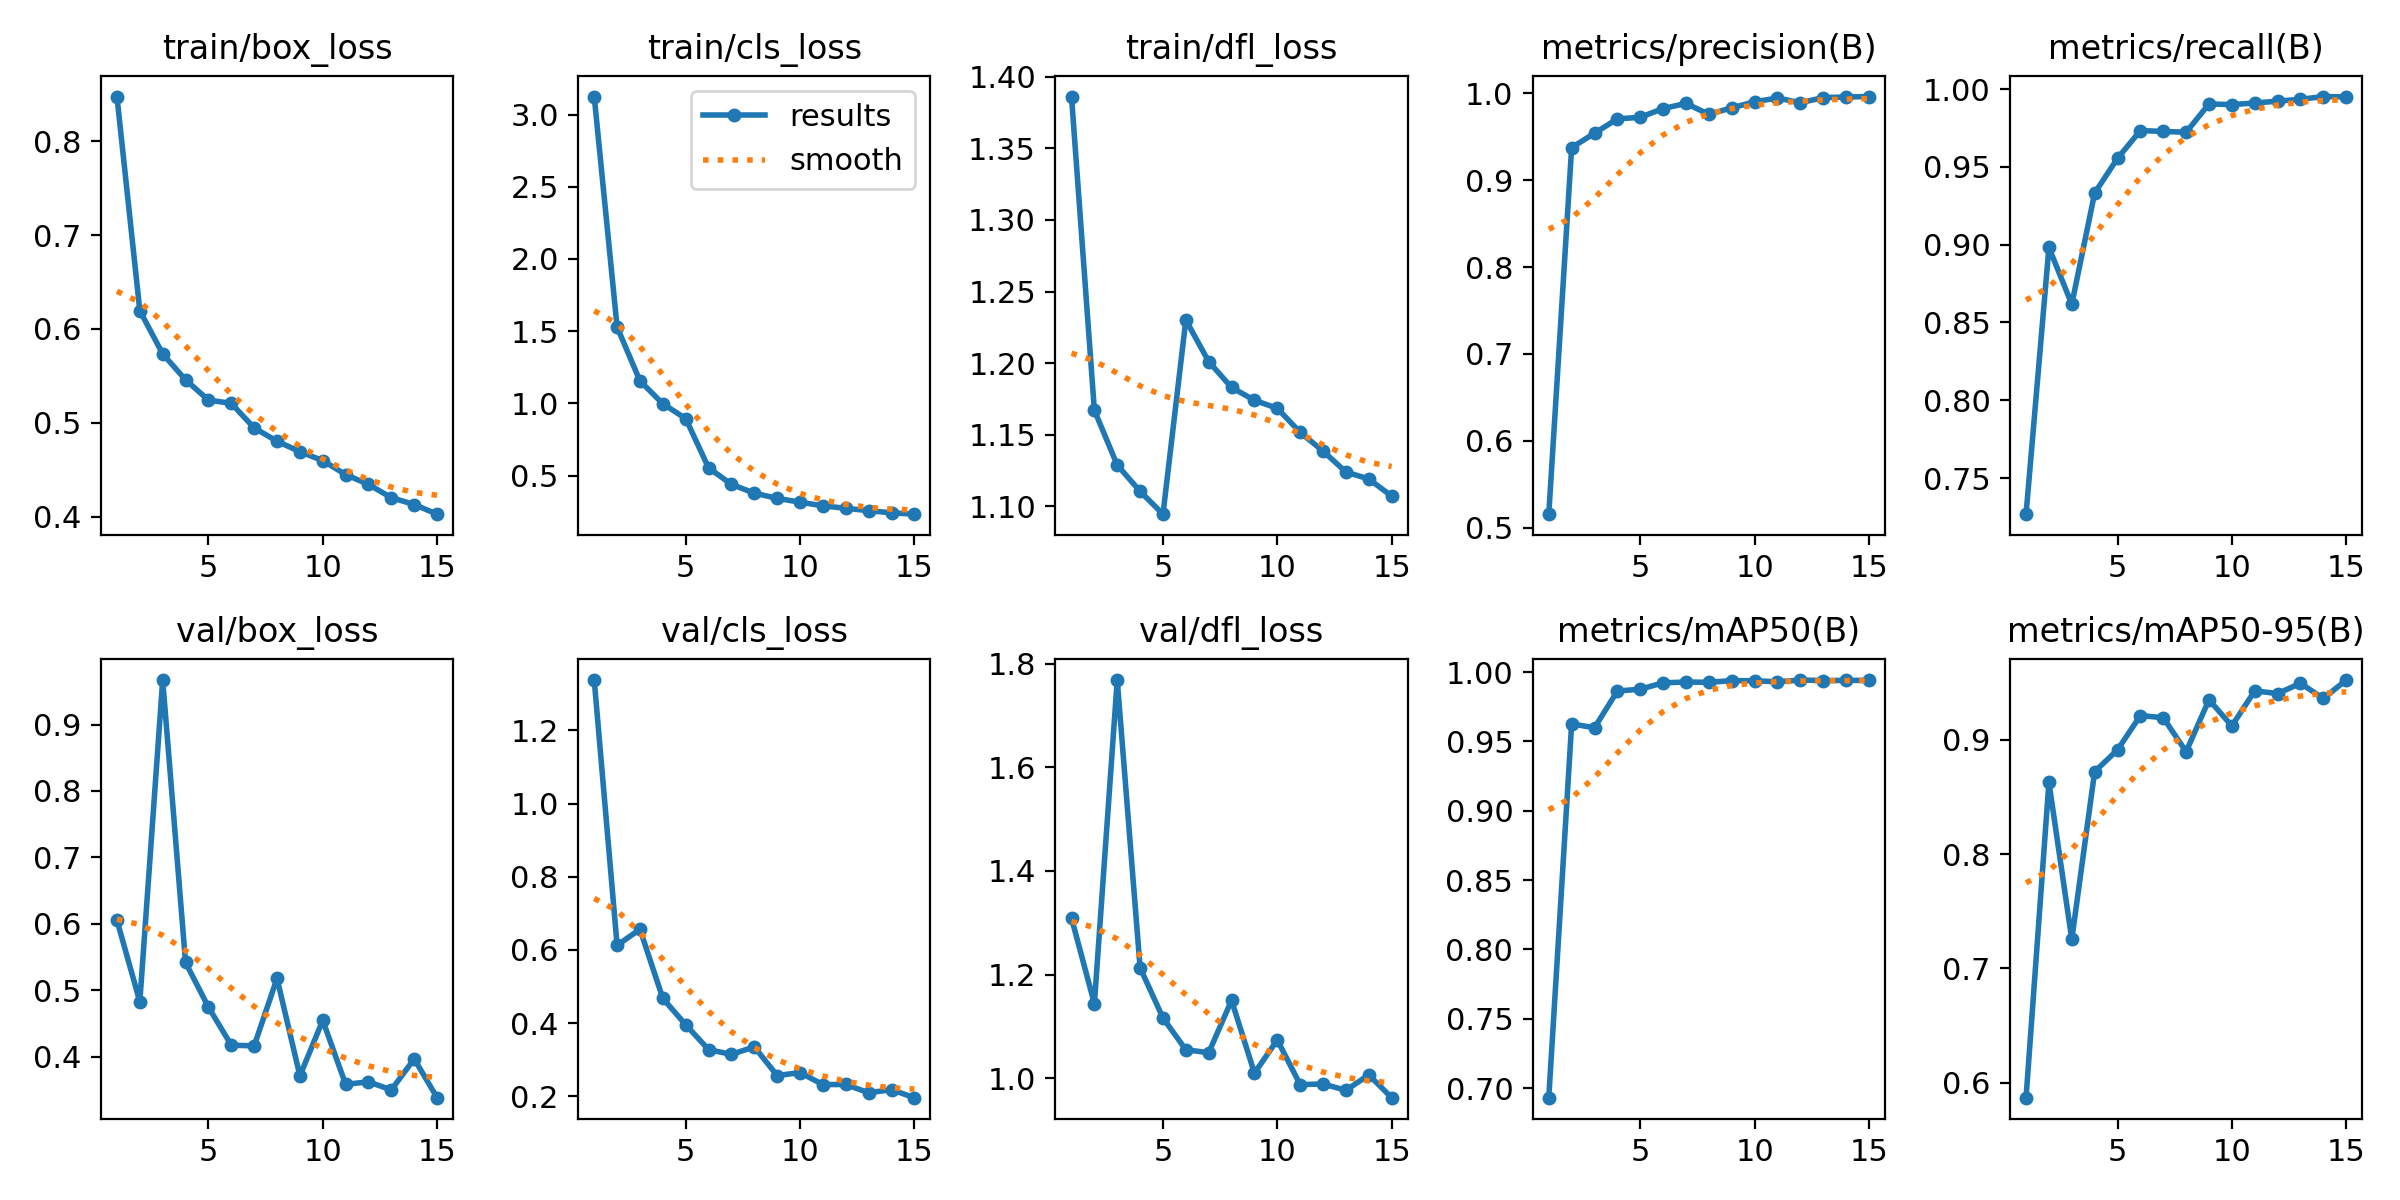

In [ ]:
from IPython.display import Image, display
import os

run_name = "custom_yolo_train2"
results_path = f"runs/detect/{run_name}/results.png"

# Check if file exists and display
if os.path.exists(results_path):
    display(Image(filename=results_path))
else:
    print(f"❌ results.png not found at: {results_path}")
    print("Make sure training completed and the path is correct.")


In [ ]:
Result_Final_model = pd.read_csv('/content/runs/detect/custom_yolo_train2/results.csv')
Result_Final_model.tail(10)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
5,6,1233.17,0.52071,0.55342,1.23013,0.98245,0.97331,0.99230,0.92130,0.41740,0.32765,1.05490,0.000231,0.000231,0.000231
6,7,1426.25,0.49451,0.43908,1.20104,0.98831,0.97275,0.99292,0.91938,0.41644,0.31461,1.04937,0.000208,0.000208,0.000208
7,8,1619.12,0.48033,0.37790,1.18299,0.97575,0.97223,0.99269,0.88965,0.51794,0.33523,1.15032,0.000186,0.000186,0.000186
8,9,1811.29,0.46916,0.34203,1.17403,0.98321,0.99042,0.99392,0.93508,0.37131,0.25679,1.00988,0.000163,0.000163,0.000163
9,10,2005.57,0.45970,0.31552,1.16841,0.99021,0.99001,0.99384,0.91218,0.45469,0.26488,1.07382,0.000140,0.000140,0.000140
10,11,2199.71,0.44480,0.29036,1.15162,0.99456,0.99101,0.99305,0.94292,0.35852,0.23217,0.98775,0.000117,0.000117,0.000117
11,12,2392.45,0.43423,0.27309,1.13857,0.98908,0.99221,0.99433,0.94052,0.36221,0.23242,0.98895,0.000095,0.000095,0.000095
12,13,2587.27,0.42013,0.25690,1.12395,0.99504,0.99340,0.99400,0.94952,0.35018,0.20983,0.97673,0.000072,0.000072,0.000072
13,14,2780.75,0.41285,0.24180,1.11903,0.99568,0.99517,0.99405,0.93621,0.39679,0.21811,1.00645,0.000049,0.000049,0.000049
14,15,2976.24,0.40255,0.23243,1.10714,0.99622,0.99494,0.99414,0.95236,0.33842,0.19639,0.96252,0.000026,0.000026,0.000026


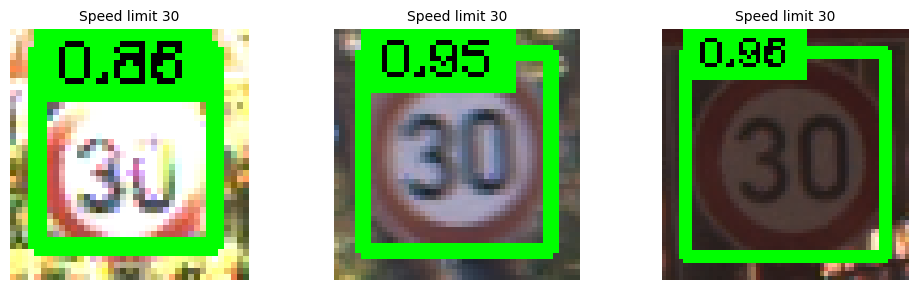

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Display 3 predictions in a row
fig, axs = plt.subplots(1, 3, figsize=(10, 3)) 

for i, result in enumerate(results[:3]):
    img = result.orig_img.copy()

    # Draw bounding boxes and score only
    for box in result.boxes.data.cpu():
        x1, y1, x2, y2, conf, cls = box.tolist()
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        label = f"{conf:.2f}"  # ✅ Only score

        color = (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.3
        thickness = 1
        (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, thickness)

        label_y = max(y1 - 10, text_height + 4)
        cv2.rectangle(
            img,
            (x1, label_y - text_height - 4),
            (x1 + text_width + 6, label_y),
            color,
            -1
        )
        cv2.putText(
            img, label,
            (x1 + 3, label_y - 3),
            font, font_scale,
            (0, 0, 0), thickness
        )

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[i].imshow(img_rgb)

    # ✅ Show predicted class name as title (top-1 prediction)
    if len(result.boxes) > 0:
        top_cls = int(result.boxes.cls[0])
        top_label = result.names[top_cls]
    else:
        top_label = "No Detection"

    axs[i].set_title(top_label, fontsize=10)
    axs[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.mp4 to test.mp4


In [ ]:
results = model.predict(
    source="/content/output.mp4",
    save=True,
    conf=0.3,
    imgsz=640
)




WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /content/output.mp4: 640x640 (no detections), 25.6ms
video 1/1 (frame 2/508) /content/output.mp4: 640x640 (no detections), 7.4ms
video 1/1 (frame 3/508) /content/output.mp4: 640x640 (no detections), 7.7ms
video 1/1 (frame 4/508) /content/output.mp4: 640x640 1 No entry, 7.4ms
video 1/1 (frame 5/508) /content/output.mp4: 640x640 (no detections), 7.4ms
video 1/1 (frame 6/508) /content/output.mp4: 640x640 (no detections), 7.5ms
vide

In [ ]:
!ffmpeg -i /content/runs/detect/predict/output.avi -vcodec libx264 /content/runs/detect/predict/output.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import HTML
from base64 import b64encode
video_path = "/content/runs/detect/predict/output.mp4"
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=640 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")